# ConvNeXt-Tiny v3 — ResNet 전략 적용

## 변경 배경

| 항목 | v2 (60.76%) | v3 (이번) | 근거 |
|------|------------|-----------|------|
| 해상도 | 320 / batch 16 | **224 / batch 32** | ResNet이 같은 조건으로 80%+ 달성 |
| 핵심 증강 | 없음 | **RandomPerspective** | 촬영 각도 왜곡이 최대 실패 원인(train.py 주석) |
| 증강 수 | 8개 (과도) | **4개** | 과도한 증강이 형태 학습 방해 |
| Loss | Focal Loss + 가중치 | **CrossEntropy** | 단순화 후 효과 검증 |
| 모델 | ConvNeXt-Tiny | **ConvNeXt-Tiny 유지** | ResNet보다 최신 아키텍처 |


## 0. 공통 설정

In [1]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm
from PIL import Image, ImageOps

# ── 재현성 고정
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'디바이스: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── 경로
DATA_DIR   = './preprocess'
TEST_DIR   = './test_final'
SAVE_DIR   = './checkpoints_v3'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── 하이퍼파라미터 (ResNet 전략 기반)
IMG_SIZE    = 224          # v2의 320 → 224로 복귀
BATCH_SIZE  = 32           # v2의 16 → 32로 복귀
WARMUP_EP   = 5
FINETUNE_EP = 40
LR_HEAD     = 1e-3
LR_FULL     = 5e-5
VAL_RATIO   = 0.2
NUM_WORKERS = 0
PATIENCE    = 10

CLASSES     = ['mug', 'straight', 'taper_smooth', 'taper_step']
NUM_CLASSES = len(CLASSES)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

print('설정 완료')

디바이스: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
설정 완료


## 1. Transform 정의

> **핵심 변경**: `RandomPerspective` 추가 — 촬영 각도(원근) 왜곡이 프로젝트 최대 실패 원인  
> 증강을 4개로 단순화 — 과도한 증강이 형태 학습을 방해했던 문제 해소

In [2]:
NORMALIZE = transforms.Normalize(mean=MEAN, std=STD)

# ── 학습용: ResNet train.py와 동일한 전략
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomPerspective(distortion_scale=0.35, p=0.4),  # ⭐ 핵심: 촬영 각도 왜곡 대응
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    NORMALIZE,
])

# ── 검증/테스트용: 팀원 전처리 방식 유지
eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    NORMALIZE,
])

print('Transform 정의 완료')
print('train 증강: RandomResizedCrop → RandomHorizontalFlip → RandomPerspective → ColorJitter')

Transform 정의 완료
train 증강: RandomResizedCrop → RandomHorizontalFlip → RandomPerspective → ColorJitter


## 2. 데이터로더 (Stratified Split + EXIF 보정)

In [3]:
from torch.utils.data import Dataset
from collections import defaultdict

def exif_safe_loader(path):
    """EXIF 방향 정보 자동 보정 (촬영 각도 문제 방지)"""
    with Image.open(path) as img:
        img = ImageOps.exif_transpose(img)
        return img.convert('RGB')

class ConnectorDataset(Dataset):
    def __init__(self, samples, transform):
        self.samples   = samples  # [(path, label), ...]
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = exif_safe_loader(path)
        return self.transform(img), label


def list_samples(root):
    samples = []
    for cls in CLASSES:
        cls_dir = os.path.join(root, cls)
        if not os.path.isdir(cls_dir):
            continue
        for name in sorted(os.listdir(cls_dir)):
            if os.path.splitext(name)[1].lower() in ('.jpg', '.jpeg', '.png'):
                samples.append((os.path.join(cls_dir, name), CLASSES.index(cls)))
    return samples


# Stratified Split
all_samples = list_samples(DATA_DIR)
labels_all  = [s[1] for s in all_samples]

train_samples, val_samples = [], []
by_class = defaultdict(list)
for s in all_samples:
    by_class[s[1]].append(s)

rng = random.Random(SEED)
for items in by_class.values():
    items = items[:]
    rng.shuffle(items)
    n_val = max(1, int(len(items) * VAL_RATIO))
    val_samples.extend(items[:n_val])
    train_samples.extend(items[n_val:])

train_loader = DataLoader(
    ConnectorDataset(train_samples, train_tf),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    ConnectorDataset(val_samples, eval_tf),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Train: {len(train_samples)}장  |  Val: {len(val_samples)}장')
from collections import Counter
tr_cnt = Counter([s[1] for s in train_samples])
for i, cls in enumerate(CLASSES):
    print(f'  {cls:14s}: train {tr_cnt[i]}장')

Train: 515장  |  Val: 127장
  mug           : train 139장
  straight      : train 141장
  taper_smooth  : train 119장
  taper_step    : train 116장


## 3. 모델 정의 (ConvNeXt-Tiny)

In [4]:
torch.manual_seed(SEED)
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f'ConvNeXt-Tiny | 총 파라미터: {total/1e6:.1f}M')

ConvNeXt-Tiny | 총 파라미터: 27.8M


## 4. 학습 함수

In [5]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            out  = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        out  = model(imgs)
        loss = criterion(out, labels)
        loss_sum += loss.item() * imgs.size(0)
        correct  += (out.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total


print('학습 함수 정의 완료')

학습 함수 정의 완료


## 5. Stage 1: Warmup (Head만 학습)

In [6]:
# CrossEntropyLoss + Label Smoothing (단순화)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Backbone 고정
for name, p in model.named_parameters():
    p.requires_grad = ('classifier' in name)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_HEAD, weight_decay=1e-4
)
scaler    = GradScaler()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=WARMUP_EP, eta_min=1e-6)

hist = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_acc, best_state, no_improve = 0.0, None, 0

print('=== Stage 1: Warmup (Head only) ===')
print(f"{'Epoch':>5}  {'Tr Loss':>8}  {'Tr Acc':>7}  {'Va Loss':>8}  {'Va Acc':>7}")
print('-' * 47)

for epoch in range(1, WARMUP_EP + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)
    hist['val_loss'].append(va_loss);   hist['val_acc'].append(va_acc)

    if va_acc > best_acc:
        best_acc = va_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    print(f"{epoch:>5}  {tr_loss:>8.4f}  {tr_acc*100:>6.2f}%  {va_loss:>8.4f}  {va_acc*100:>6.2f}%")

print(f'\nWarmup 완료 | Best Val Acc: {best_acc*100:.2f}%')

C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_51532\426067643.py:12: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()


=== Stage 1: Warmup (Head only) ===
Epoch   Tr Loss   Tr Acc   Va Loss   Va Acc
-----------------------------------------------


C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_51532\1758199554.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


    1    1.0848   65.63%    0.7311   89.76%
    2    0.7425   84.85%    0.5666   91.34%
    3    0.6300   90.68%    0.5348   92.91%
    4    0.5935   90.29%    0.5219   94.49%
    5    0.5658   93.40%    0.5199   94.49%

Warmup 완료 | Best Val Acc: 94.49%


## 6. Stage 2: Finetune (전체 모델)

In [7]:
for p in model.parameters():
    p.requires_grad = True

# Backbone 낮은 LR, Classifier 높은 LR
optimizer = optim.AdamW([
    {'params': model.features.parameters(),    'lr': LR_FULL},
    {'params': model.classifier.parameters(),  'lr': LR_FULL * 10},
], weight_decay=1e-4)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=FINETUNE_EP, eta_min=1e-7)
scaler     = GradScaler()
no_improve = 0

print('=== Stage 2: Finetune (전체) ===')
print(f"{'Epoch':>5}  {'Tr Loss':>8}  {'Tr Acc':>7}  {'Va Loss':>8}  {'Va Acc':>7}")
print('-' * 47)

for epoch in tqdm(range(1, FINETUNE_EP + 1), desc='Finetune'):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    scheduler.step()

    hist['train_loss'].append(tr_loss); hist['train_acc'].append(tr_acc)
    hist['val_loss'].append(va_loss);   hist['val_acc'].append(va_acc)

    if va_acc > best_acc:
        best_acc   = va_acc
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\nEarly stopping @ epoch {epoch + WARMUP_EP}')
            break

    if epoch % 5 == 0:
        print(f"{epoch+WARMUP_EP:>5}  {tr_loss:>8.4f}  {tr_acc*100:>6.2f}%  {va_loss:>8.4f}  {va_acc*100:>6.2f}%")

save_path = os.path.join(SAVE_DIR, 'best_convnext_v3.pth')
torch.save(best_state, save_path)
print(f'\n최고 Val Acc: {best_acc*100:.2f}%  →  {save_path}')

C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_51532\4078520011.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = GradScaler()


=== Stage 2: Finetune (전체) ===
Epoch   Tr Loss   Tr Acc   Va Loss   Va Acc
-----------------------------------------------


Finetune:   0%|          | 0/40 [00:00<?, ?it/s]C:\Users\한국전파진흥협회\AppData\Local\Temp\ipykernel_51532\1758199554.py:7: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Finetune:  12%|█▎        | 5/40 [01:50<08:28, 14.53s/it]

   10    0.3848   99.61%    0.4180   97.64%


Finetune:  25%|██▌       | 10/40 [02:27<04:12,  8.41s/it]

   15    0.3828   99.03%    0.4033   97.64%


Finetune:  30%|███       | 12/40 [03:00<07:00, 15.02s/it]


Early stopping @ epoch 18



최고 Val Acc: 97.64%  →  ./checkpoints_v3\best_convnext_v3.pth


## 7. 학습 곡선

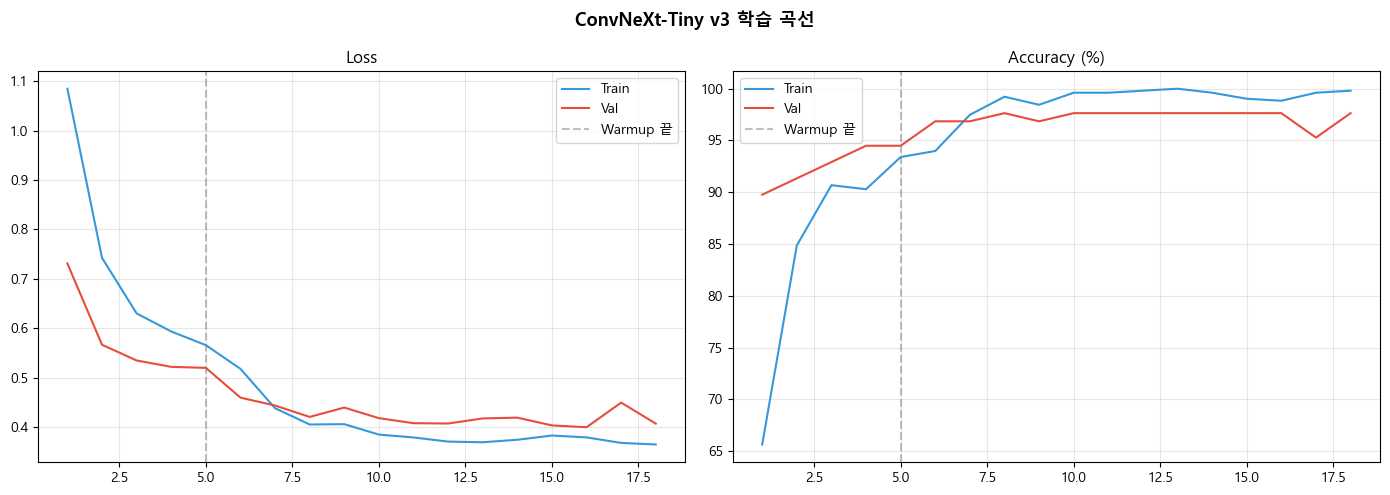

In [8]:
epochs = range(1, len(hist['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ConvNeXt-Tiny v3 학습 곡선', fontsize=13, fontweight='bold')

axes[0].plot(epochs, hist['train_loss'], label='Train', color='#3498DB')
axes[0].plot(epochs, hist['val_loss'],   label='Val',   color='#E74C3C')
axes[0].axvline(WARMUP_EP, color='gray', linestyle='--', alpha=0.5, label='Warmup 끝')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, [v*100 for v in hist['train_acc']], label='Train', color='#3498DB')
axes[1].plot(epochs, [v*100 for v in hist['val_acc']],   label='Val',   color='#E74C3C')
axes[1].axvline(WARMUP_EP, color='gray', linestyle='--', alpha=0.5, label='Warmup 끝')
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'train_curve_v3.png'), dpi=150)
plt.show()

## 8. Test 평가 — 클래스별 성능 분석

> `test_shape_classifier.py` 방식을 따라 **클래스별로 개별 평가** 후 결과 시각화
> - 단순 추론 (TTA 없이) → 클래스별 Accuracy / Recall 확인
> - 오분류 샘플 우선 표시 → 어떤 이미지를 틀렸는지 직접 확인

In [9]:
# ── 모델 로드 (최고 Val Acc 기준)
model.load_state_dict(best_state)
model.eval()

# ── 테스트 이미지 로드
test_samples   = list_samples(TEST_DIR)
test_img_paths = [s[0] for s in test_samples]
test_labels    = [s[1] for s in test_samples]

print(f'테스트 이미지 수: {len(test_samples)}장')
from collections import Counter
cnt = Counter(test_labels)
for i, cls in enumerate(CLASSES):
    print(f'  {cls:14s}: {cnt[i]}장')


# ── 단순 추론 (eval_tf, 1-pass)
@torch.no_grad()
def predict_single(img_path, model, transform):
    img  = exif_safe_loader(img_path)
    inp  = transform(img).unsqueeze(0).to(DEVICE)
    out  = model(inp)
    probs = torch.softmax(out, dim=1).squeeze().cpu().numpy()
    return int(probs.argmax()), probs


all_preds, all_probs = [], []
for path in tqdm(test_img_paths, desc='추론'):
    pred, probs = predict_single(path, model, eval_tf)
    all_preds.append(pred)
    all_probs.append(probs)

acc = sum(p == t for p, t in zip(all_preds, test_labels)) / len(test_labels)
print(f'\n전체 Test Accuracy: {acc*100:.2f}%')
print('\n=== 클래스별 성능 (test_shape_classifier 방식) ===')
print(classification_report(test_labels, all_preds, target_names=CLASSES))

# ── 클래스별 개별 결과 출력 (pytest.mark.parametrize 방식)
print('\n' + '='*50)
print('  클래스별 상세 결과')
print('='*50)
for cls_idx, cls_name in enumerate(CLASSES):
    cls_indices = [i for i, l in enumerate(test_labels) if l == cls_idx]
    correct = sum(all_preds[i] == cls_idx for i in cls_indices)
    total   = len(cls_indices)
    recall  = correct / total if total > 0 else 0
    status  = 'PASS ✅' if recall >= 0.7 else 'FAIL ❌'
    # 오분류 내역
    errors  = {}
    for i in cls_indices:
        if all_preds[i] != cls_idx:
            errors[CLASSES[all_preds[i]]] = errors.get(CLASSES[all_preds[i]], 0) + 1
    err_str = ', '.join(f'{k}:{v}' for k, v in errors.items()) if errors else '없음'
    print(f'  {status}  {cls_name:14s}  Recall {recall*100:5.1f}%  ({correct}/{total})')
    print(f'         오분류 → {err_str}')
print('='*50)

테스트 이미지 수: 158장
  mug           : 27장
  straight      : 50장
  taper_smooth  : 41장
  taper_step    : 40장


추론: 100%|██████████| 158/158 [00:24<00:00,  6.49it/s]


전체 Test Accuracy: 82.91%

=== 클래스별 성능 (test_shape_classifier 방식) ===
              precision    recall  f1-score   support

         mug       1.00      0.74      0.85        27
    straight       0.81      0.84      0.82        50
taper_smooth       0.68      0.73      0.71        41
  taper_step       0.93      0.97      0.95        40

    accuracy                           0.83       158
   macro avg       0.85      0.82      0.83       158
weighted avg       0.84      0.83      0.83       158


  클래스별 상세 결과
  PASS ✅  mug             Recall  74.1%  (20/27)
         오분류 → taper_smooth:5, taper_step:1, straight:1
  PASS ✅  straight        Recall  84.0%  (42/50)
         오분류 → taper_smooth:8
  PASS ✅  taper_smooth    Recall  73.2%  (30/41)
         오분류 → taper_step:2, straight:9
  PASS ✅  taper_step      Recall  97.5%  (39/40)
         오분류 → taper_smooth:1


## 9. 클래스별 샘플 시각화 — 오분류 우선 표시

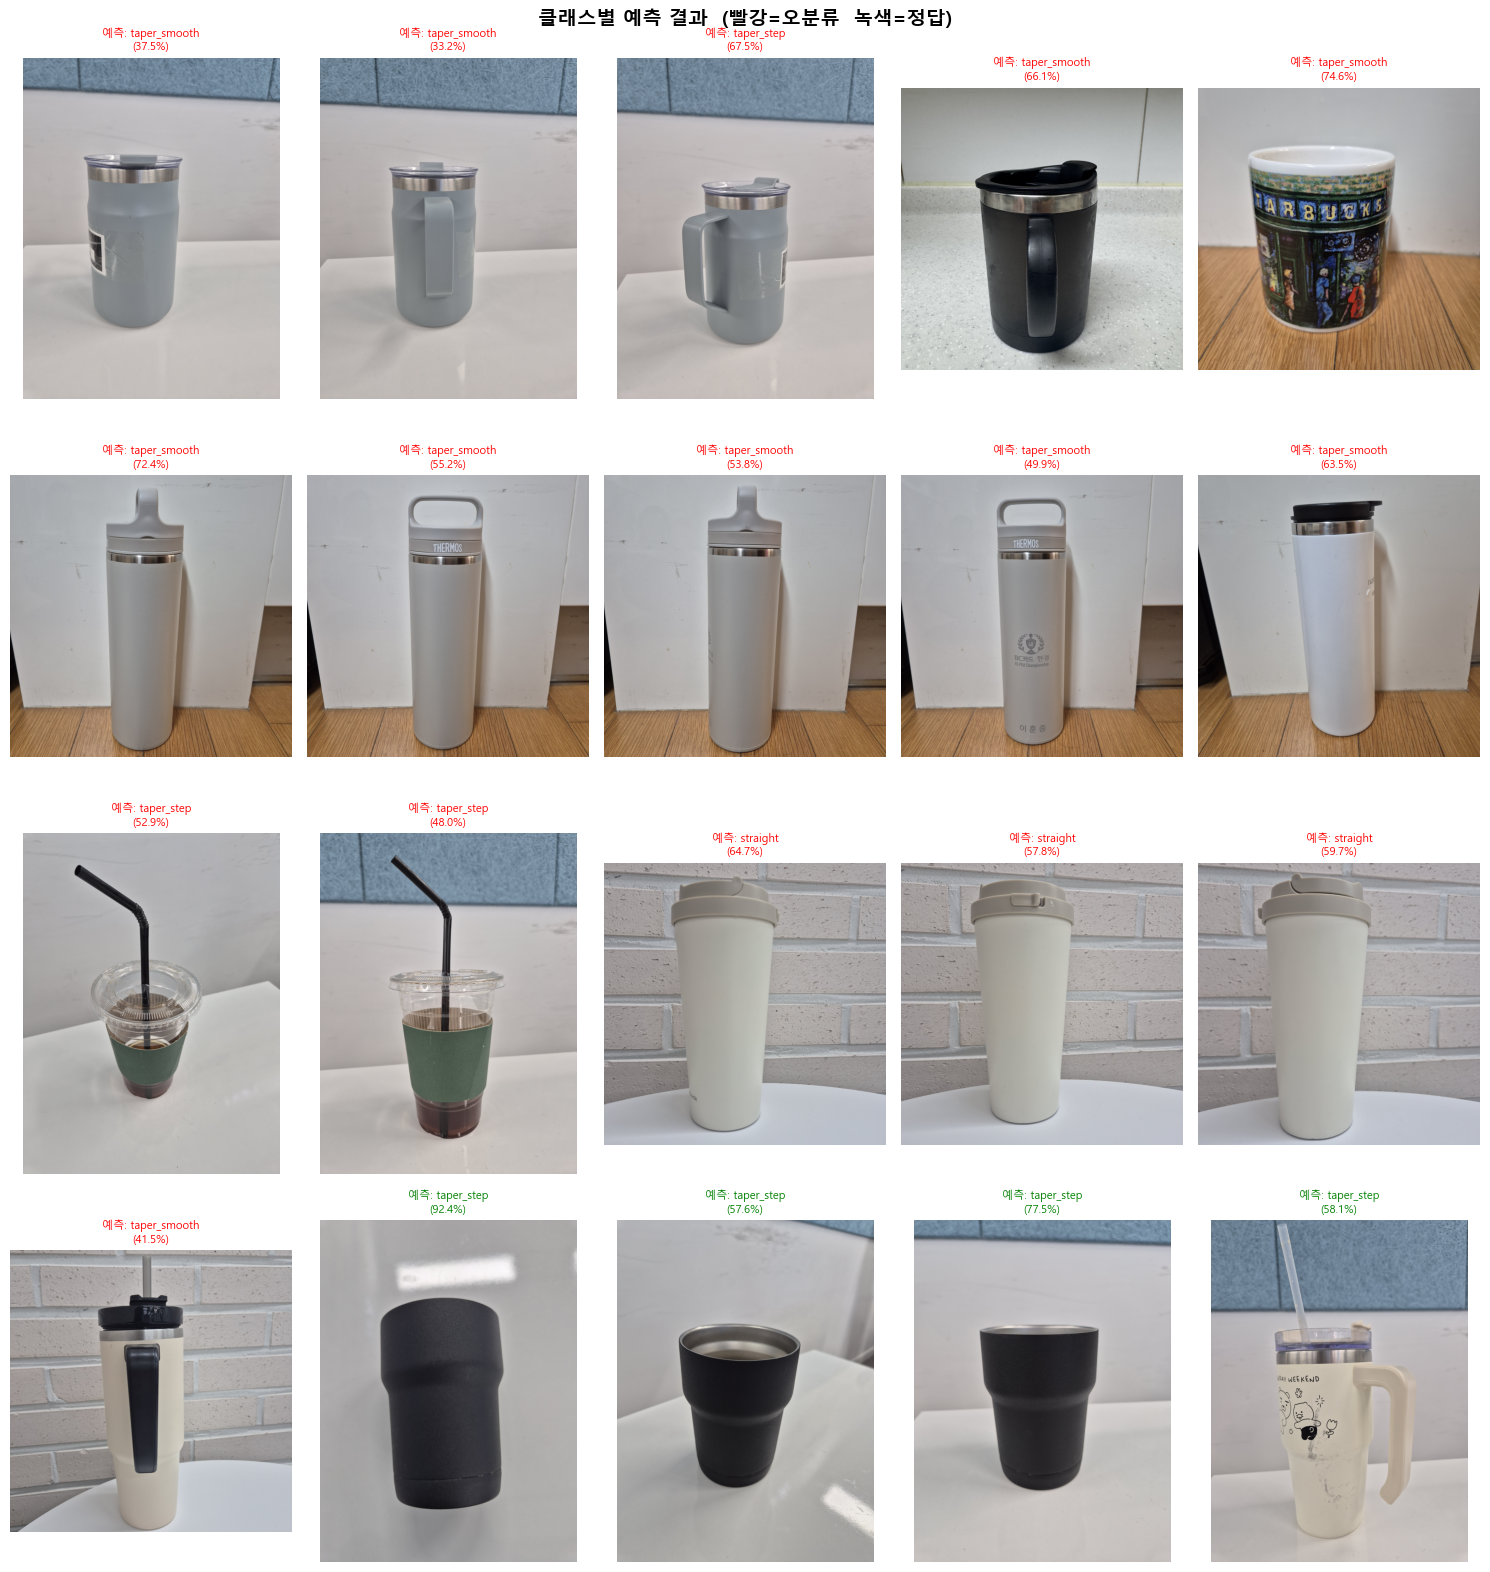

클래스별 샘플 시각화 저장 완료


In [10]:
# 각 클래스별 샘플: 오분류(빨강) 먼저, 정답(녹색) 나중 — test_shape_classifier 방식
N_SHOW = 5
fig, axes = plt.subplots(NUM_CLASSES, N_SHOW, figsize=(3 * N_SHOW, 4 * NUM_CLASSES))
fig.suptitle('클래스별 예측 결과  (빨강=오분류  녹색=정답)', fontsize=14, fontweight='bold')

for cls_idx, cls_name in enumerate(CLASSES):
    cls_indices = [i for i, l in enumerate(test_labels) if l == cls_idx]
    wrong_idx   = [i for i in cls_indices if all_preds[i] != cls_idx]
    right_idx   = [i for i in cls_indices if all_preds[i] == cls_idx]
    show_idx    = (wrong_idx + right_idx)[:N_SHOW]

    cls_recall = sum(all_preds[i] == cls_idx for i in cls_indices) / max(len(cls_indices), 1)

    for col, idx in enumerate(show_idx):
        img     = exif_safe_loader(test_img_paths[idx])
        correct = (all_preds[idx] == cls_idx)
        conf    = all_probs[idx][all_preds[idx]] * 100
        title   = f'예측: {CLASSES[all_preds[idx]]}\n({conf:.1f}%)'
        axes[cls_idx][col].imshow(img)
        axes[cls_idx][col].set_title(title, fontsize=8,
                                      color='green' if correct else 'red')
        axes[cls_idx][col].axis('off')
        if col == 0:
            axes[cls_idx][col].set_ylabel(
                f'{cls_name}\nRecall {cls_recall*100:.0f}%',
                fontsize=9, rotation=90, va='center')

    for col in range(len(show_idx), N_SHOW):   # 빈 칸
        axes[cls_idx][col].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'samples_v3.png'), dpi=120, bbox_inches='tight')
plt.show()
print('클래스별 샘플 시각화 저장 완료')

## 10. Confusion Matrix

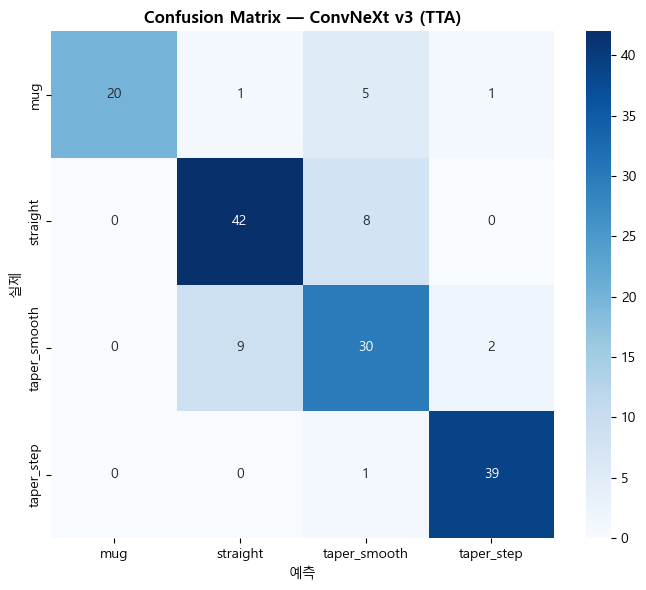

taper_smooth → straight 오분류: 9건
straight → taper_smooth 오분류: 8건


In [11]:
cm = confusion_matrix(test_labels, all_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_title('Confusion Matrix — ConvNeXt v3 (TTA)', fontsize=12, fontweight='bold')
ax.set_ylabel('실제'); ax.set_xlabel('예측')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cm_v3.png'), dpi=150)
plt.show()

sm_idx = CLASSES.index('taper_smooth')
st_idx = CLASSES.index('straight')
print(f'taper_smooth → straight 오분류: {cm[sm_idx][st_idx]}건')
print(f'straight → taper_smooth 오분류: {cm[st_idx][sm_idx]}건')

## 11. GradCAM — taper_smooth vs straight

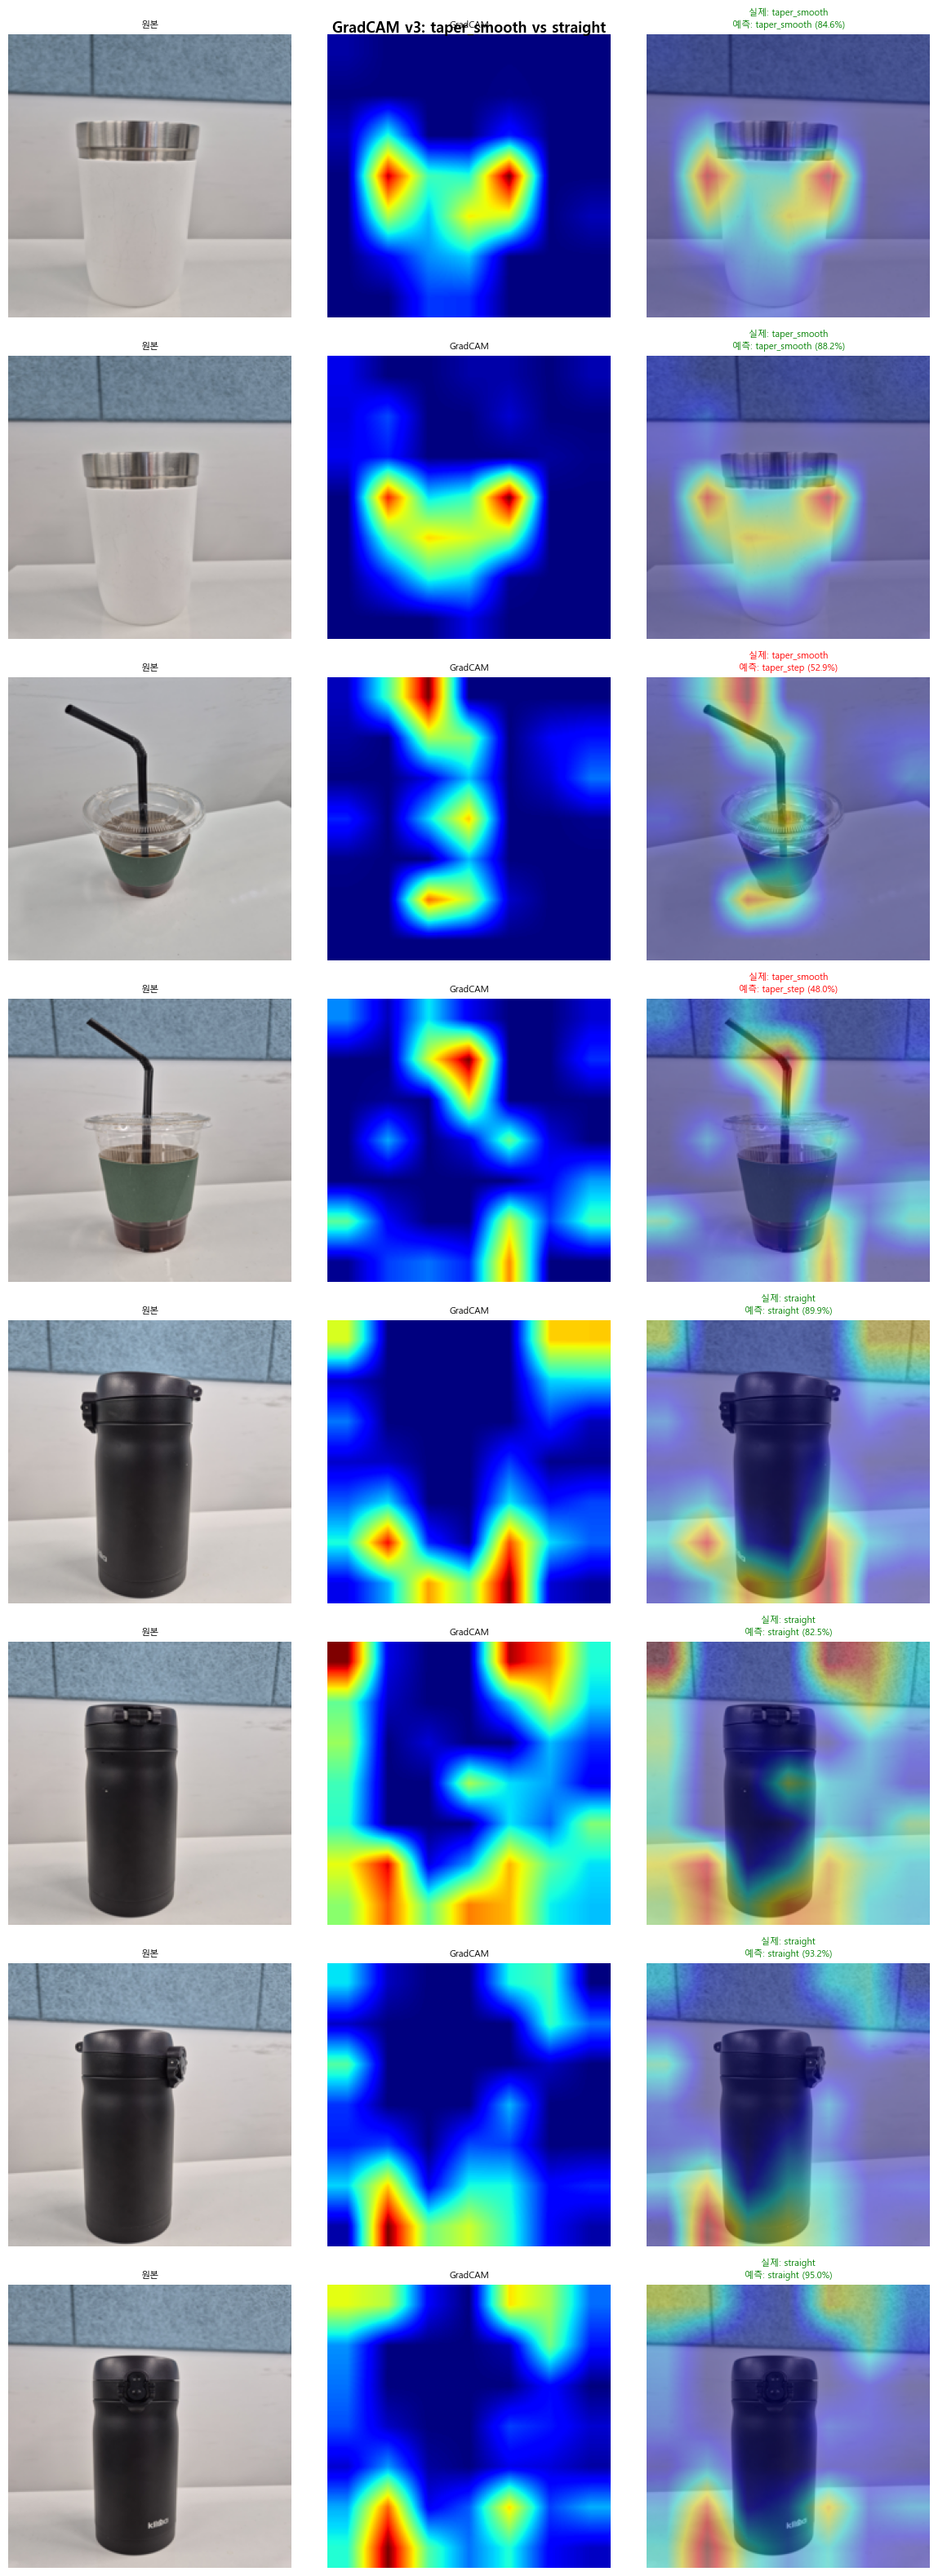

GradCAM 저장 완료


In [12]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0][class_idx] = 1
        output.backward(gradient=one_hot, retain_graph=True)
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:],
                            mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx, output.softmax(1).squeeze().detach().cpu().numpy()


gradcam = GradCAM(model, model.features[-2][-1])
target_cls      = ['taper_smooth', 'straight']
samples_per_cls = 4

fig, axes = plt.subplots(len(target_cls) * samples_per_cls, 3,
                          figsize=(12, 4 * len(target_cls) * samples_per_cls))
fig.suptitle('GradCAM v3: taper_smooth vs straight', fontsize=13, fontweight='bold')

row = 0
for cls_name in target_cls:
    cls_idx   = CLASSES.index(cls_name)
    cls_paths = [test_img_paths[i] for i, l in enumerate(test_labels) if l == cls_idx]
    for path in cls_paths[:samples_per_cls]:
        img_orig    = exif_safe_loader(path)
        img_resized = np.array(img_orig.resize((IMG_SIZE, IMG_SIZE)))
        inp = eval_tf(img_orig).unsqueeze(0).to(DEVICE)
        cam, pred_idx, probs = gradcam.generate(inp)

        heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        overlay = (img_resized * 0.6 + heatmap * 0.4).astype(np.uint8)

        correct = (pred_idx == cls_idx)
        title   = f'실제: {cls_name}\n예측: {CLASSES[pred_idx]} ({probs[pred_idx]*100:.1f}%)'

        axes[row][0].imshow(img_resized)
        axes[row][0].set_title('원본', fontsize=8); axes[row][0].axis('off')
        axes[row][1].imshow(cam, cmap='jet')
        axes[row][1].set_title('GradCAM', fontsize=8); axes[row][1].axis('off')
        axes[row][2].imshow(overlay)
        axes[row][2].set_title(title, fontsize=8, color='green' if correct else 'red')
        axes[row][2].axis('off')
        row += 1

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'gradcam_v3.png'), dpi=120, bbox_inches='tight')
plt.show()
print('GradCAM 저장 완료')

## 12. 최종 결과 요약

In [ ]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(test_labels, all_preds, average='macro')
per_f1   = f1_score(test_labels, all_preds, average=None)

print('┌──────────────────────────────────────────────────┐')
print('│          ConvNeXt-Tiny v3 최종 결과              │')
print('├──────────────────────────────────────────────────┤')
print(f'│  Test Accuracy (TTA) : {acc*100:>6.2f}%                   │')
print(f'│  Macro F1            : {macro_f1:>6.4f}                   │')
print('├──────────────────────────────────────────────────┤')
for i, cls in enumerate(CLASSES):
    print(f'│  {cls:14s} F1 : {per_f1[i]:>6.4f}                   │')
print('├──────────────────────────────────────────────────┤')
print('│  v3 핵심 변경사항                                 │')
print('│  ✅ RandomPerspective 추가 (각도 왜곡 대응)       │')
print('│  ✅ 증강 단순화 (8개 → 4개)                       │')
print('│  ✅ 해상도 320 → 224 / 배치 16 → 32              │')
print('│  ✅ CrossEntropyLoss (Focal Loss 제거)            │')
print('│  ✅ EXIF 방향 자동 보정                           │')
print('└──────────────────────────────────────────────────┘')